Welcome to Voxelmap!

The first thing we'll do is train the neural network (Network A). We'll then test the network to see how it performs.

# Imports


## Imports and Setup

This cell initializes the core libraries required for the experiment.

- Standard Python utilities for timing, file system access, and numerical computation
- PyTorch for deep learning, optimization, and dataset handling
- Matplotlib for visualization
- Project-specific modules for network definitions and loss functions
- Warning suppression to keep notebook output clean

These imports form the foundation for model training, evaluation, and result analysis in subsequent cells.


In [1]:
import sys
from pathlib import Path

# Path to staged_approach folder (the one that contains utilities/)
STAGED_ROOT = Path("/home/saatwik/Desktop/ImageX_VoxelMap/staged_approach")

# Put it at the front so it wins over the other utilities/
sys.path.insert(0, str(STAGED_ROOT))

# optional sanity check
import utilities
print("utilities imported from:", utilities.__file__)


utilities imported from: /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/utilities/__init__.py


In [2]:

# imports
import time
import os
import numpy as np
from matplotlib import pyplot as plt
from utilities import losses
from utilities.losses import PerceptualLoss, PerceptualLossMask,image_l1_mask
import torch
from torch.utils.data import Dataset
import torch.optim as optim
import warnings
import random

warnings.filterwarnings("ignore")

from networks2 import StagedNetwork


# File Names

## Experiment Configuration

This cell defines the experiment metadata and dataset configuration.

- Specifies patient identifier, treatment day, and dataset type
- Selects scatter or no-scatter data (Scatter is added in Treatment day 2 Dataset)
- Constructs the input image directory based on the chosen configuration
- Defines experiment description and output filename for logging and checkpoints

This configuration block ensures consistency and reproducibility across training runs.


In [3]:
random.seed(42)

In [4]:

import os

Patient_number = "P2"
NoScatter = True
Scatter = False
DatasetType = "SPARE"
DayofTreatment = 1
NetworkType = "STAGED"

if NoScatter == Scatter:
    raise ValueError("Set exactly one of NoScatter or Scatter to True.")

scatter_tag = "NS" if NoScatter else "SC"

im_dir = os.path.join(
    "/srv/shared/SPARE",
    f"MC_V_{Patient_number}_{scatter_tag}_{DayofTreatment:02d}"
)

run_name = "staged_P2_iteration3_l1_mask"
weights_dir = os.path.join("weights", run_name)
os.makedirs(weights_dir, exist_ok=True)
stage_a_ckpt = os.path.join(weights_dir, "stageA_best.pth")


# Stage B checkpoint name - configurable for different loss experiments
stage_b_loss_name = "l1"  # Options: 'l1', 'perceptual', etc.
stage_b_ckpt = os.path.join(weights_dir, f"stageB_{stage_b_loss_name}_best.pth")

plot_dir = os.path.join("plots", run_name)
os.makedirs(plot_dir, exist_ok=True)

# Training hyper-parameters
im_size = 128
int_steps = 10
train_batch_size = 4
val_batch_size = 4
stage_a_epochs = 50
stage_b_epochs = 50
motion_lr = 1e-4
image_lr = 5e-5
image_loss_type = "l1"  # choices: 'l1' or 'perceptual'
perceptual_slices = 16

print(f"Training data: {im_dir}")

print(f"Weights directory: {weights_dir}")

print(f"Stage A checkpoint: {stage_a_ckpt}")
print(f"Image loss type: {image_loss_type}")
print(f"Stage B checkpoint: {stage_b_ckpt}")

Training data: /srv/shared/SPARE/MC_V_P2_NS_01
Weights directory: weights/staged_P2_iteration3_l1_mask
Stage A checkpoint: weights/staged_P2_iteration3_l1_mask/stageA_best.pth
Image loss type: l1
Stage B checkpoint: weights/staged_P2_iteration3_l1_mask/stageB_l1_best.pth


# Setup Dataset

## Supervised Dataset Definition

This cell defines a custom PyTorch `Dataset` for supervised training.

- Loads source and target projections, volumes, and deformation vector fields (DVFs) from disk
- Applies min–max normalization to projection and volume data
- Constructs source–target pairs based on filename conventions
- Reshapes data into channel-first tensors compatible with PyTorch models
- Returns a dictionary containing all inputs and ground truth required for training

This dataset class standardizes data access and preprocessing for the training pipeline.


In [5]:

# set up training dataset class
class SupervisedDataset(Dataset):
    def __init__(self, im_dir=None, im_size=None):
        self.im_dir = im_dir
        self.im_size = im_size
        self.proj_list = sorted([n for n in os.listdir(self.im_dir) if n.endswith('_bin.npy')])
        if not self.proj_list:
            raise RuntimeError(f"No projection *.npy files found in {im_dir}")

    def __len__(self):
        return len(self.proj_list)

    def _normalize(self, arr):
        arr = arr.astype(np.float32)
        mn, mx = float(arr.min()), float(arr.max())
        if mx - mn < 1e-6:
            return np.zeros_like(arr, dtype=np.float32)
        return (arr - mn) / (mx - mn)

    def __getitem__(self, idx):
        target_file = self.proj_list[idx]
        proj_name = os.path.join(self.im_dir, target_file)
        target_proj = self._normalize(np.load(proj_name))

        vol_num = target_file[:2]
        dvf_name = os.path.join(self.im_dir, f'DVF_{vol_num}_mha.npy')
        target_dvf = np.load(dvf_name)

        source_file = '06_' + target_file[3:]
        source_proj = self._normalize(np.load(os.path.join(self.im_dir, source_file)))

        source_vol = self._normalize(np.load(os.path.join(self.im_dir, 'subCT_06_mha.npy')))
        source_hull = self._normalize(np.load(os.path.join(self.im_dir, 'sub_Abdomen_mha.npy')))

        source_projections = source_proj[None, ...].astype(np.float32)
        target_projections = target_proj[None, ...].astype(np.float32)

        source_volumes = source_vol[None, ...].astype(np.float32)
        source_abdomen = source_hull[None, ...].astype(np.float32)

        target_flow = np.zeros((3, self.im_size, self.im_size, self.im_size), dtype=np.float32)
        target_flow[0] = target_dvf[:, :, :, 0]
        target_flow[1] = target_dvf[:, :, :, 1]
        target_flow[2] = target_dvf[:, :, :, 2]

        data = {
            'source_projections': torch.from_numpy(source_projections),
            'target_projections': torch.from_numpy(target_projections),
            'source_volumes': torch.from_numpy(source_volumes),
            'source_abdomen': torch.from_numpy(source_abdomen),
            'target_flow': torch.from_numpy(target_flow),
        }

        return data


Lookin' good! Now we will create training and validation datasets

## Data Loading and Visualization

This cell creates a test data loader and retrieves a single example from the dataset.

- Initializes the dataset and `DataLoader` with batch size 1
- Extracts source projections, target projections, volumes, abdomen mask, and DVF
- Visualizes:
  - The source projection
  - A central axial slice from the source volume
  - A mid-slice component of the target deformation vector field (DVF)

This step provides a quick sanity check to verify data integrity, orientation, and alignment before training.


Network time! Let's set up a cuda implementation of the network, a loss function (good ol' MSE will do! but we're computing it within a thoracoabdominal mask) and an optimizer

It's important to note that , this difference is because there could have been changes to the anatomy between planning and treatment day.

# Training


## Training Setup (Staged)

We now split the dataset, initialize the `StagedNetwork`, and train in two passes:

1. **Stage A** – optimize encoder + motion decoder with supervised DVF loss.
2. **Stage B** – freeze the motion path, then train the image decoder using L1 + perceptual losses.

Checkpoints for each stage are written to `weights/{run_name}` so we can resume or evaluate later.


In [6]:

# generate train/val split
batch_size = train_batch_size
val_batch = val_batch_size

dataset = SupervisedDataset(im_dir=im_dir, im_size=im_size)
split = [int(len(dataset) * 0.9), len(dataset) - int(len(dataset) * 0.9)]
trainset, valset = torch.utils.data.random_split(dataset, split)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=val_batch, shuffle=False)

print(f"Train samples: {len(trainset)} | Val samples: {len(valset)}")


Train samples: 6120 | Val samples: 680


In [7]:

import torch

from utilities import spatialTransform
from utilities import losses

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = StagedNetwork(
    im_size=im_size,
    int_steps=int_steps,
    skip_connections=True,
).to(device)

motion_loss_fn = losses.flow_mask()
image_l1_loss = losses.image_l1_mask()
perceptual_loss = (
    losses.PerceptualLoss(
        layer_index=8,
        slices_per_vol=perceptual_slices,
        device='cuda' if torch.cuda.is_available() else 'cpu',
        sampling_mode='random',
    )
    if image_loss_type == 'perceptual'
    else None
)

def compute_image_loss(pred, target, mask):  # Added mask parameter
    #if image_loss_type == 'perceptual':
     #   if perceptual_loss_mask is None:
     #       raise RuntimeError("Perceptual loss requested but not initialized")
     #   return perceptual_loss_mask(pred, target, mask)  # Pass mask
    return image_l1_loss.loss(target, pred, mask)


def to_tanh_range(x):
    return (x * 2.0) - 1.0

spatial_transformer = spatialTransform.Network([im_size, im_size, im_size]).to(device).eval()


Using device: cuda:0


In [8]:
import time

# =========================
# OPTIMIZED STAGED TRAINING
# =========================

def train_stage_a():
    history = {'train': [], 'val': []}
    best_val = float('inf')

    model.set_stage('A')
    optimizer = optim.Adam(
        (p for p in model.parameters() if p.requires_grad),
        lr=motion_lr
    )

    epoch_times = []

    for epoch in range(1, stage_a_epochs + 1):
        epoch_start = time.time()

        model.set_stage('A')
        model.train()
        running = 0.0

        for batch in trainloader:
            source_proj = batch['source_projections'].to(device)
            target_proj = batch['target_projections'].to(device)
            source_vol = batch['source_volumes'].to(device)
            target_flow = batch['target_flow'].to(device)
            abdomen_mask = batch['source_abdomen'].to(device)

            optimizer.zero_grad()
            _, pred_flow = model(
                source_proj, target_proj, source_vol, stage='A'
            )
            loss = motion_loss_fn.loss(
                target_flow, pred_flow, abdomen_mask
            )
            loss.backward()
            optimizer.step()

            running += loss.item() * source_proj.size(0)

        train_loss = running / len(trainloader.dataset)

        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for batch in valloader:
                source_proj = batch['source_projections'].to(device)
                target_proj = batch['target_projections'].to(device)
                source_vol = batch['source_volumes'].to(device)
                target_flow = batch['target_flow'].to(device)
                abdomen_mask = batch['source_abdomen'].to(device)

                _, pred_flow = model(
                    source_proj, target_proj, source_vol, stage='A'
                )
                val_running += (
                    motion_loss_fn.loss(
                        target_flow, pred_flow, abdomen_mask
                    ).item() * source_proj.size(0)
                )

        val_loss = val_running / len(valloader.dataset)
        history['train'].append(train_loss)
        history['val'].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(
                {'epoch': epoch, 'model_state': model.state_dict()},
                stage_a_ckpt
            )

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)
        avg_time = sum(epoch_times) / len(epoch_times)

        print(
            f"[Stage A][Epoch {epoch:03d}] "
            f"train={train_loss:.6f} "
            f"val={val_loss:.6f} "
            f"best={best_val:.6f} | "
            f"time={epoch_time:.1f}s "
            f"(avg {avg_time:.1f}s)"
        )

    return history


def train_stage_b():
    """
    Optimized Stage B with feature caching.
    """
    history = {'train': [], 'val': []}
    best_val = float('inf')

    model.set_stage('B')
    optimizer = optim.Adam(
        (p for p in model.parameters() if p.requires_grad),
        lr=image_lr
    )

    epoch_times = []

    for epoch in range(1, stage_b_epochs + 1):
        epoch_start = time.time()

        model.set_stage('B')
        model.train()
        running = 0.0

        # ----------------
        # Training
        # ----------------
        for batch in trainloader:
            source_proj = batch['source_projections'].to(device)
            target_proj = batch['target_projections'].to(device)
            source_vol = batch['source_volumes'].to(device)
            target_flow = batch['target_flow'].to(device)
            abdomen_mask = batch['source_abdomen'].to(device)  # ADDED


            with torch.no_grad():
                target_volume = spatial_transformer(
                    source_vol, target_flow
                )

                model.set_stage('A')
                model.eval()
                _, _, cache = model(
                    source_proj,
                    target_proj,
                    source_vol,
                    stage='A',
                    return_cache=True
                )

            model.set_stage('B')
            model.train()
            optimizer.zero_grad()

            synth = model(
                source_proj,
                target_proj,
                source_vol,
                stage='B',
                cached_features=cache
            )
            synth = torch.tanh(synth)

            target = to_tanh_range(target_volume)
            image_loss = compute_image_loss(synth, target, abdomen_mask)  # Pass mask

            image_loss.backward()
            optimizer.step()

            running += image_loss.item() * source_proj.size(0)

        train_loss = running / len(trainloader.dataset)

        # ----------------
        # Validation
        # ----------------
        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for batch in valloader:
                source_proj = batch['source_projections'].to(device)
                target_proj = batch['target_projections'].to(device)
                source_vol = batch['source_volumes'].to(device)
                target_flow = batch['target_flow'].to(device)
                abdomen_mask = batch['source_abdomen'].to(device)  # ADDED


                target_volume = spatial_transformer(
                    source_vol, target_flow
                )

                model.set_stage('A')
                _, _, cache = model(
                    source_proj,
                    target_proj,
                    source_vol,
                    stage='A',
                    return_cache=True
                )

                model.set_stage('B')
                synth = model(
                    source_proj,
                    target_proj,
                    source_vol,
                    stage='B',
                    cached_features=cache
                )
                synth = torch.tanh(synth)

                target = to_tanh_range(target_volume)

                image_loss = compute_image_loss(synth, target, abdomen_mask)  # Pass mask

                val_running += (
                    image_loss.item() * source_proj.size(0)
                )

        val_loss = val_running / len(valloader.dataset)
        history['train'].append(train_loss)
        history['val'].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(
                {'epoch': epoch, 'model_state': model.state_dict()},
                stage_b_ckpt
            )

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)
        avg_time = sum(epoch_times) / len(epoch_times)

        print(
            f"[Stage B][Epoch {epoch:03d}] "
            f"train={train_loss:.6f} "
            f"val={val_loss:.6f} "
            f"best={best_val:.6f} | "
            f"time={epoch_time:.1f}s "
            f"(avg {avg_time:.1f}s)"
        )

    return history


# ----------------
# Main training
# ----------------


In [ ]:
#stage_a_history = train_stage_a()


In [9]:
stage_a_history = train_stage_a()

print(stage_a_ckpt)
if os.path.exists(stage_a_ckpt):
    ckpt = torch.load(stage_a_ckpt, map_location=device)
    model.load_state_dict(ckpt['model_state'])

stage_b_history = train_stage_b()

[Stage A][Epoch 001] train=0.324427 val=0.111631 best=0.111631 | time=1369.9s (avg 1369.9s)
[Stage A][Epoch 002] train=0.091253 val=0.051607 best=0.051607 | time=1385.5s (avg 1377.7s)
[Stage A][Epoch 003] train=0.049289 val=0.040226 best=0.040226 | time=1395.6s (avg 1383.6s)
[Stage A][Epoch 004] train=0.036750 val=0.032369 best=0.032369 | time=1395.2s (avg 1386.5s)
[Stage A][Epoch 005] train=0.034848 val=0.029041 best=0.029041 | time=1395.5s (avg 1388.3s)
[Stage A][Epoch 006] train=0.031842 val=0.025831 best=0.025831 | time=1400.1s (avg 1390.3s)
[Stage A][Epoch 007] train=0.028573 val=0.022037 best=0.022037 | time=1393.7s (avg 1390.8s)
[Stage A][Epoch 008] train=0.016125 val=0.009244 best=0.009244 | time=1395.8s (avg 1391.4s)
[Stage A][Epoch 009] train=0.013707 val=0.033949 best=0.009244 | time=1381.3s (avg 1390.3s)
[Stage A][Epoch 010] train=0.007256 val=0.005649 best=0.005649 | time=1391.2s (avg 1390.4s)
[Stage A][Epoch 011] train=0.007559 val=0.028941 best=0.005649 | time=1389.3s (a

===== Stage A Metrics =====
Stage A train: last=0.000080 | best=0.000080 | epochs=50
Stage A val: last=0.000186 | best=0.000066 | epochs=50
===== Stage B Metrics =====
Stage B train: last=0.024357 | best=0.024357 | epochs=50
Stage B val: last=0.029309 | best=0.029290 | epochs=50


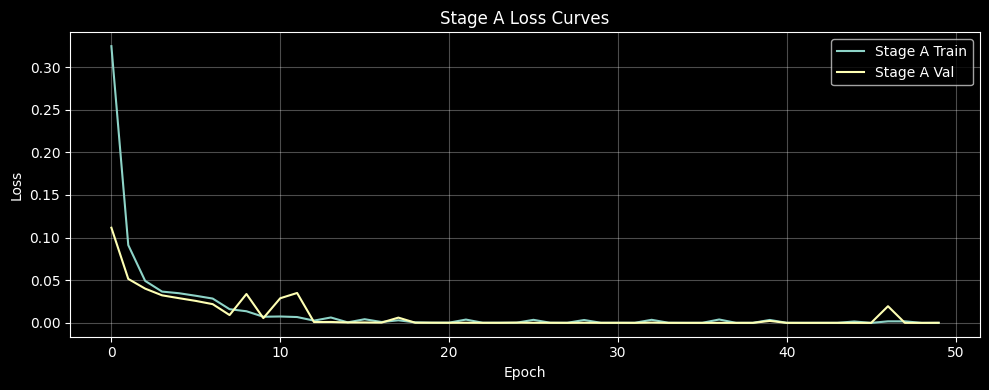

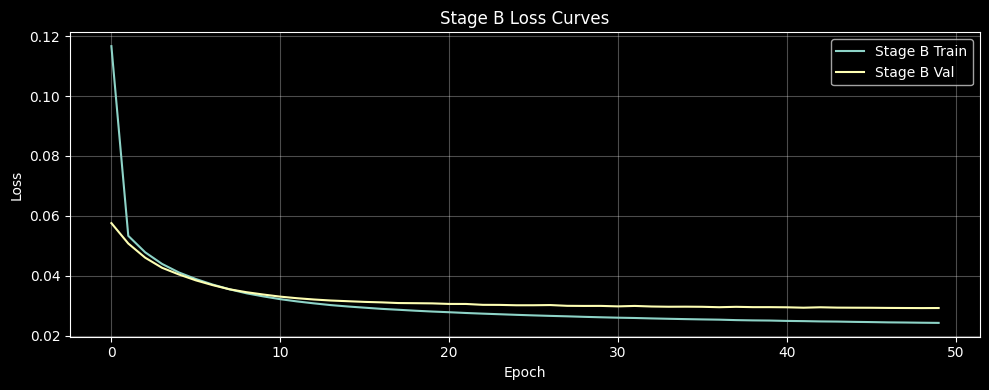

In [11]:

# =========================
# Metrics logging + plotting
# =========================
import numpy as np
import matplotlib.pyplot as plt

metrics_dir = os.path.join(plot_dir, 'training_metrics')
os.makedirs(metrics_dir, exist_ok=True)

np.save(os.path.join(metrics_dir, 'stageA_train.npy'), np.asarray(stage_a_history['train'], dtype=float))
np.save(os.path.join(metrics_dir, 'stageA_val.npy'), np.asarray(stage_a_history['val'], dtype=float))
np.save(os.path.join(metrics_dir, 'stageB_train.npy'), np.asarray(stage_b_history['train'], dtype=float))
np.save(os.path.join(metrics_dir, 'stageB_val.npy'), np.asarray(stage_b_history['val'], dtype=float))

print("===== Stage A Metrics =====")
for split in ('train', 'val'):
    values = np.asarray(stage_a_history[split], dtype=float)
    print(f"Stage A {split}: last={values[-1]:.6f} | best={values.min():.6f} | epochs={len(values)}")

print("===== Stage B Metrics =====")
for split in ('train', 'val'):
    values = np.asarray(stage_b_history[split], dtype=float)
    print(f"Stage B {split}: last={values[-1]:.6f} | best={values.min():.6f} | epochs={len(values)}")

plt.figure(figsize=(10,4))
plt.plot(stage_a_history['train'], label='Stage A Train')
plt.plot(stage_a_history['val'], label='Stage A Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Stage A Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, 'stageA_loss.png'), dpi=200)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(stage_b_history['train'], label='Stage B Train')
plt.plot(stage_b_history['val'], label='Stage B Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Stage B Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, 'stageB_loss.png'), dpi=200)
plt.show()


# Testing

## Setting File Names

## File and Directory Configuration for Day 2

This cell sets up paths and filenames for the Day 2 scatter dataset.

- Defines patient ID, dataset type, treatment day, and network type
- Ensures exactly `Scatter`  is selected
- Constructs the input image directory based on scatter configuration
- Defines experiment filename and test dataset path
- Sets the folder for saving processed outputs and target ITVs
- Prints paths for verification and easy access in subsequent cells

This setup centralizes file references and ensures reproducibility for Day 2 evaluation.


In [12]:

# file names
import os

Patient_number = "P2"
NoScatter = False
Scatter = True
DatasetType = "SPARE"
DayofTreatment = 2
NetworkType = "STAGED"

if NoScatter == Scatter:
    raise ValueError("Set exactly one of NoScatter or Scatter to True.")

scatter_tag = "NS" if NoScatter else "SC"

im_dir = os.path.join(
    "/srv/shared/SPARE",
    f"MC_V_{Patient_number}_{scatter_tag}_{DayofTreatment:02d}"
)

expt_file = f'{DatasetType}_{NetworkType}_{Patient_number}'
test_file = im_dir

Saved_folder = "/home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/"
target_itv_ptv_dir = f"{Saved_folder}Target_ITVs_ALL_{DatasetType}_{NetworkType}_{Patient_number}"

run_name = "staged_P2_iteration3_l1_mask"
weights_dir = os.path.join("weights", run_name)
stage_a_ckpt = os.path.join(weights_dir, "stageA_best.pth")
stage_b_ckpt = os.path.join(weights_dir, "stageB_best.pth")

print(test_file)
print(target_itv_ptv_dir)


/srv/shared/SPARE/MC_V_P2_SC_02
/home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITVs_ALL_SPARE_STAGED_P2


## Obtaining  Target PTV for All 680 Projections

## Generate Target ITV PTVs

This cell generates target ITV (Internal Target Volume) PTVs for all breathing phases and organizes them for later use.

- Defines helper functions to ensure source PTVs and DVFs have correct 5D shape
- Uses a spatial transformer network to warp source PTVs using DVFs for 10 breathing phases
- Saves warped target PTVs in a dedicated output directory
- Reads `RespBin.csv` to map breathing phases to target indices
- Copies generated PTVs into a centralized folder for all targets
- Prints progress every 50 targets and confirms completion

This process produces all target volumes needed for evaluation or downstream analysis.


In [13]:
import os
import numpy as np
import torch
from utilities import spatialTransform


def _ensure_src_ptv_5d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    if x.ndim == 3:
        x = x[None, None, ...]
    elif x.ndim == 5:
        pass
    else:
        raise ValueError(f"Unsupported source PTV shape {x.shape}")
    return x.astype(np.float32)


def _ensure_dvf_5d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    if x.ndim == 4 and x.shape[-1] == 3:
        x = np.transpose(x, (3, 0, 1, 2))[None, ...]
    elif x.ndim == 4 and x.shape[0] == 3:
        x = x[None, ...]
    elif x.ndim == 5 and x.shape[1] == 3:
        pass
    else:
        raise ValueError(f"Unsupported DVF shape {x.shape}")
    return x.astype(np.float32)

# source ptv changes wrt Patient
def generate_target_itv_ptv_10bins(
    im_dir: str,
    out_dir: str,
    im_size: int = 128,
    dvf_folder: str | None = None,
    #source_ptv_relpath: str = os.path.join("source", "itv_PTV_mha.npy"),
    source_ptv_relpath: str = os.path.join("itv_PTV_mha.npy"),
    dvf_pattern: str = "DVF_{:02d}_mha.npy",
    out_pattern: str = "Target_ITV_PTV_{:02d}_mha.npy",
):
    """
    Saves Target ITV PTVs into out_dir.
    """
    if dvf_folder is None:
        dvf_folder = im_dir

    os.makedirs(out_dir, exist_ok=True)

    src_ptv_path = os.path.join(im_dir, source_ptv_relpath)
    if not os.path.exists(src_ptv_path):
        raise FileNotFoundError(f"Missing source ITV PTV: {src_ptv_path}")

    source_ptv_np = _ensure_src_ptv_5d(np.load(src_ptv_path))
    if source_ptv_np.shape[-3:] != (im_size, im_size, im_size):
        raise ValueError(f"Source PTV spatial shape {source_ptv_np.shape[-3:]} != {(im_size,)*3}")

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    transformer = spatialTransform.Network([im_size, im_size, im_size]).to(device).eval()

    source_ptv_t = torch.from_numpy(source_ptv_np).to(device)

    for b in range(1, 11):
        dvf_path = os.path.join(dvf_folder, dvf_pattern.format(b))
        if not os.path.exists(dvf_path):
            raise FileNotFoundError(f"Missing DVF file: {dvf_path}")

        dvf_np = _ensure_dvf_5d(np.load(dvf_path))
        if dvf_np.shape[-3:] != (im_size, im_size, im_size):
            raise ValueError(f"DVF spatial shape mismatch for {dvf_path}")

        dvf_t = torch.from_numpy(dvf_np).to(device)

        with torch.no_grad():
            tgt_ptv_t = transformer(source_ptv_t, dvf_t)

        tgt_ptv_np = tgt_ptv_t.detach().cpu().numpy()  # [1,1,D,H,W]

        out_path = os.path.join(out_dir, out_pattern.format(b))
        np.save(out_path, tgt_ptv_np)
        print(f"Saved {out_path}")

    print("Done. Target ITV PTVs saved.")




# Save into MC_V_P1_SC_02/Target_ITV/
generate_target_itv_ptv_10bins(
    im_dir=test_file,
    out_dir=f"{Saved_folder}Target_ITV_{DatasetType}_{NetworkType}_{Patient_number}",
    im_size=128,
)


Saved /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITV_SPARE_STAGED_P2/Target_ITV_PTV_01_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITV_SPARE_STAGED_P2/Target_ITV_PTV_02_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITV_SPARE_STAGED_P2/Target_ITV_PTV_03_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITV_SPARE_STAGED_P2/Target_ITV_PTV_04_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITV_SPARE_STAGED_P2/Target_ITV_PTV_05_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITV_SPARE_STAGED_P2/Target_ITV_PTV_06_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITV_SPARE_STAGED_P2/Target_ITV_PTV_07_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITV_SPARE_STAGED_P2/Target_ITV_PTV_08_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITV_SPARE_STAGED_P2/Target_IT

In [14]:
import os
import shutil
import csv

# -----------------------------
# Paths
# -----------------------------
target_itv_dir = f"{Saved_folder}Target_ITV_{DatasetType}_{NetworkType}_{Patient_number}"
respbin_csv = f"{test_file}/RespBin.csv"
output_dir = f"{Saved_folder}Target_ITVs_ALL_{DatasetType}_{NetworkType}_{Patient_number}"

os.makedirs(output_dir, exist_ok=True)

targets_created = 0

# -----------------------------
# Read CSV and create ITVs
# -----------------------------
with open(respbin_csv, newline='') as csvfile:
    reader = csv.reader(csvfile)

    for target_idx, row in enumerate(reader, start=1):

        # Skip empty rows
        if not row:
            continue

        # Single column = breathing phase
        breathing_phase = int(row[0])
        if not (1 <= breathing_phase <= 10):
            raise ValueError(
                f"Invalid breathing phase {breathing_phase} at target {target_idx}"
            )

        phase_str = f"{breathing_phase:02d}"

        src_itv = os.path.join(
            target_itv_dir,
            f"Target_ITV_PTV_{phase_str}_mha.npy"
        )

        if not os.path.exists(src_itv):
            raise FileNotFoundError(f"Missing ITV file: {src_itv}")

        dst_itv = os.path.join(
            output_dir,
            f"Target_{target_idx:05d}_ITV_PTV.npy"
        )

        shutil.copy(src_itv, dst_itv)
        targets_created += 1

        if targets_created % 50 == 0:
            print(f"Processed {targets_created} targets...")

print(f"\n Successfully created {targets_created} Target ITV PTVs")
print(f" Output directory: {output_dir}")


Processed 50 targets...
Processed 100 targets...
Processed 150 targets...
Processed 200 targets...
Processed 250 targets...
Processed 300 targets...
Processed 350 targets...
Processed 400 targets...
Processed 450 targets...
Processed 500 targets...
Processed 550 targets...
Processed 600 targets...
Processed 650 targets...

 Successfully created 680 Target ITV PTVs
 Output directory: /home/saatwik/Desktop/ImageX_VoxelMap/staged_approach/Target_ITVs_ALL_SPARE_STAGED_P2


## Preparing testing Functions

## Validation Dataset for SPARE

This cell defines a PyTorch `Dataset` class for validation of SPARE data.

- Loads target projections, volumes, and associated PTVs using `RespBin.csv` for phase mapping
- Uses Phase 06 as the reference source projection and volume
- Loads restricted contours (PTV) from the source folder
- Reads projection angles from `Angles.csv`
- Reshapes all volumes and projections into channel-first tensors compatible with PyTorch
- Returns a dictionary containing all inputs and ground truth for model evaluation

This class standardizes the validation data pipeline for consistency with training data.


In [15]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class validateSPAREDataset(Dataset):
    def __init__(self, im_dir=None, im_size=None):
        self.im_dir = im_dir
        # Source files (Phase 06) and global contours are in the 'source' subfolder Within the Treatment Day Dataset
        self.ref_dir = os.path.join(im_dir, 'source')
        self.im_size = im_size

    def __len__(self):
        # Count target projections (excluding phase 06 reference files)
        return len([n for n in os.listdir(self.im_dir) if n.endswith('_bin.npy') and not n.startswith('06_')])

    def __getitem__(self, idx):
        # 1. Find target projection
        proj_list = sorted([n for n in os.listdir(self.im_dir) if n.endswith('_bin.npy') and not n.startswith('06_')])
        target_file = proj_list[idx]
        target_proj = np.load(os.path.join(self.im_dir, target_file))

        # 2. Find target volume using RespBin.csv logic
        resp_bin_path = os.path.join(self.im_dir, 'RespBin.csv')
        resp_bins = np.genfromtxt(resp_bin_path)
        bin_val = int(resp_bins[idx])

        # Format the volume number (e.g., 1 -> '01', 10 -> '10')
        if bin_val < 10:
            vol_num = '0' + str(bin_val)
        else:
            vol_num = str(bin_val) # Assuming 10 is the max, else use str(bin_val)

        # Load the volume corresponding to the bin index
        target_vol = np.load(os.path.join(self.im_dir, f'subCT_{vol_num}_mha.npy'))

        # 3. Find source data (Reference Phase 06) from the 'source' folder
        # Reconstructs source filename (e.g., 01_Proj_001.npy -> 06_Proj_001.npy)
        source_proj_name = '06_'+"Proj_" + '_'.join(target_file.split('_')[1:])
        source_proj = np.load(os.path.join(self.ref_dir, source_proj_name))

        source_vol = np.load(os.path.join(self.im_dir, 'subCT_06_mha.npy'))

        # 4. Find restricted contours (Lung and PTV only) from 'source' folder
        #source_lung = np.load(os.path.join(self.ref_dir, 'itv_Lung_mha.npy'))
        #source_ptv = np.load(os.path.join(self.ref_dir, 'itv_PTV_mha.npy'))
        # Patient 2 has itv_PTV_mha.npy outside source folder
        source_ptv = np.load(os.path.join(self.im_dir, 'itv_PTV_mha.npy'))


        # 5. Load Angle
        angle_data = np.genfromtxt(os.path.join(self.im_dir, 'Angles.csv'))
        angle = angle_data[idx]

        # Find target contours
        target_num = target_file.split('_')
        target_num = target_num[1]


        vol_name = os.path.join(target_itv_ptv_dir, format('Target_' + target_num + '_ITV_PTV.npy'))
        target_ptv = np.load(vol_name)

        # 6. Reshape and convert to Tensors
        def to_tensor(data, is_vol=True):
            if is_vol:
                out = np.zeros((1, self.im_size, self.im_size, self.im_size), dtype=np.float32)
                out[0, ...] = np.asarray(data)
            else:
                out = np.zeros((1, self.im_size, self.im_size), dtype=np.float32)
                out[0, ...] = np.asarray(data)
            return torch.from_numpy(out)

        data = {
            'source_projections': to_tensor(source_proj, is_vol=False),
            'target_projections': to_tensor(target_proj, is_vol=False),
            'source_volumes': to_tensor(source_vol),
            #'source_lung': to_tensor(source_lung), # If available use it
            'source_ptv': to_tensor(source_ptv),
            'target_volumes': to_tensor(target_vol),
            'angle': angle,
            'target_ptv' :to_tensor(target_ptv)
        }

        return data

## Initiating Testing

## Test Loader and Model Setup

This cell prepares the validation data loader and loads the trained model.

- Initializes the `validateSPAREDataset` and creates a `DataLoader` with batch size 1
- Sets up the network architecture and moves it to GPU if available
- Loads the best-performing model weights from the training phase
- Switches the model to evaluation mode
- Prints the total number of trainable parameters for reference

This setup ensures the model is ready for inference on the validation/test dataset.


In [16]:

# Generate test loader
batch_size = 1
im_size = 128

dataset = validateSPAREDataset(im_dir=test_file, im_size=im_size)
testloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

model = StagedNetwork(
    im_size=im_size,
    int_steps=int_steps,
    skip_connections=True,
)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

ckpt_path = stage_b_ckpt if os.path.exists(stage_b_ckpt) else stage_a_ckpt
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"No checkpoint found at {ckpt_path}")

ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.set_stage('A')
model.eval()

print(f"Loaded checkpoint: {ckpt_path}")
print('Number of parameters: %d' % (sum(p.numel() for p in model.parameters() if p.requires_grad)))


Loaded checkpoint: weights/staged_P2_iteration3_l1_mask/stageA_best.pth
Number of parameters: 14507757


## Testing and Evaluation Loop

This following cells run inference on the test dataset and computes multiple evaluation metrics.

- Loads source projections, volumes, and PTVs from the validation loader
- Predicts DVFs using the trained model
- Warps the source PTV and volume using the predicted DVF via a spatial transformer
- Computes predicted and ground-truth centroid shifts in LR, SI, and AP directions
- Calculates Dice similarity for PTV overlap
- Computes Jacobian determinant ratio to check DVF regularity
- Records gantry angles for each sample
- Computes image quality metrics: MSE, SSIM, and PSNR between predicted and target volumes
- Prints debug information for the first few samples and progress every 10 samples

This loop provides a comprehensive assessment of both geometric and intensity-based performance of the model.


In [17]:
# Load transformer
from utilities import spatialTransform
transformer = spatialTransform.Network([im_size, im_size, im_size])
transformer.to(device)

Network(
  (transformer): SpatialTransformer()
)

In [19]:

from utilities.helpers import centroid_shift_mm
centroid = losses.centroid_ptv()
dice = losses.dice()
jacobian_determinant = losses.jacobian_determinant()
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Tracking metrics
tar_lr, tar_si, tar_ap = [], [], []
pred_lr, pred_si, pred_ap = [], [], []
test_angles = []

# Regularity / overlap
test_dice = []
test_detJ = []

# Stage A image quality (motion-warped)
test_mse, test_ssim, test_psnr = [], [], []

# Stage B image quality (image decoder)
stageb_mse, stageb_ssim, stageb_psnr = [], [], []

print("Testing...")

for i, data in enumerate(testloader, 0):
    source_proj = data['source_projections'].to(device)
    target_proj = data['target_projections'].to(device)
    source_vol = data['source_volumes'].to(device)
    target_vol = data['target_volumes'].to(device)
    source_ptv = data['source_ptv'].to(device)
    target_ptv = data['target_ptv'].to(device)
    angle = data['angle'].to(device)

    with torch.no_grad():
        stage_a_volume, pred_flow, cache = model(
            source_proj,
            target_proj,
            source_vol,
            stage='A',
            return_cache=True,
        )

    pred_ptv = transformer.forward(source_ptv, pred_flow)

    pred_lr_mm, pred_si_mm, pred_ap_mm = centroid_shift_mm(
        centroid, source_ptv, pred_ptv
    )
    pred_lr.append(pred_lr_mm)
    pred_si.append(pred_si_mm)
    pred_ap.append(pred_ap_mm)

    gt_lr_mm, gt_si_mm, gt_ap_mm = centroid_shift_mm(
        centroid, source_ptv, target_ptv
    )
    tar_lr.append(gt_lr_mm)
    tar_si.append(gt_si_mm)
    tar_ap.append(gt_ap_mm)

    dice_sim = dice.loss(target_ptv, pred_ptv)
    test_dice.append(float(dice_sim.item()))

    disp = np.zeros((im_size, im_size, im_size, 3), dtype=np.float32)
    metric_flows = np.squeeze(pred_flow.detach().cpu().numpy())
    disp[:, :, :, 0] = metric_flows[0]
    disp[:, :, :, 1] = metric_flows[1]
    disp[:, :, :, 2] = metric_flows[2]

    detJ = jacobian_determinant.loss(disp)
    detJ_ratio = sum(j <= 0 for j in detJ.flatten()) / detJ.size
    test_detJ.append(float(detJ_ratio))

    test_angles.append(float(angle.item()))

    predict_vol = stage_a_volume
    metric_input = target_vol.detach().cpu().numpy().flatten()
    metric_pred = predict_vol.detach().cpu().numpy().flatten()

    mse_val = np.sqrt(np.mean(np.square(metric_input - metric_pred)))
    ssim_val = ssim(
        metric_input,
        metric_pred,
        data_range=(np.max(metric_pred) - np.min(metric_pred) + 1e-8)
    )
    psnr_val = psnr(metric_input, metric_pred)

    test_mse.append(float(mse_val))
    test_ssim.append(float(ssim_val))
    test_psnr.append(float(psnr_val))

    sample_pred = None
    sample_target = None
    with torch.no_grad():
        stage_b_logits = model(
            source_proj,
            target_proj,
            source_vol,
            stage='B',
            cached_features=cache,
        )
    stage_b_pred = torch.tanh(stage_b_logits)
    stage_b_pred = (stage_b_pred + 1.0) / 2.0
    if sample_pred is None:
            sample_pred = stage_b_pred[0].cpu()
            sample_target = target_vol[0].cpu()

    stageb_metric_pred = stage_b_pred.detach().cpu().numpy().flatten()
    stageb_mse.append(float(np.sqrt(np.mean(np.square(metric_input - stageb_metric_pred)))))
    stageb_ssim.append(float(ssim(
        metric_input,
        stageb_metric_pred,
        data_range=(np.max(stageb_metric_pred) - np.min(stageb_metric_pred) + 1e-8)
    )))
    stageb_psnr.append(float(psnr(metric_input, stageb_metric_pred)))

    if i < 5:
        print(f"[DBG idx={i}] angle={angle.item():.2f}")
        print("[DBG pred mm lr,si,ap]", pred_lr_mm, pred_si_mm, pred_ap_mm)
        print("[DBG gt   mm lr,si,ap]", gt_lr_mm, gt_si_mm, gt_ap_mm)

    if i % 10 == 0:
        print(f"{i} of {len(testloader)}")


Testing...
[DBG idx=0] angle=0.00
[DBG pred mm lr,si,ap] -1.9139289855957031 6.144549560546875 1.7011871337890625
[DBG gt   mm lr,si,ap] -1.799734115600586 5.416596984863281 2.6054134368896484
0 of 680
[DBG idx=1] angle=0.53
[DBG pred mm lr,si,ap] -1.9124336242675781 6.145470428466797 1.7020149230957031
[DBG gt   mm lr,si,ap] -1.799734115600586 5.416596984863281 2.6054134368896484
[DBG idx=2] angle=1.06
[DBG pred mm lr,si,ap] -1.8719253540039062 6.112461853027344 1.6138420104980469
[DBG gt   mm lr,si,ap] 0.3572711944580078 4.085683441162109 1.2632865905761719
[DBG idx=3] angle=1.59
[DBG pred mm lr,si,ap] -1.8781604766845703 6.1304382324218745 1.636526107788086
[DBG gt   mm lr,si,ap] 0.3572711944580078 4.085683441162109 1.2632865905761719
[DBG idx=4] angle=2.12
[DBG pred mm lr,si,ap] -1.8831138610839844 6.124394226074219 1.6506786346435547
[DBG gt   mm lr,si,ap] 0.3572711944580078 4.085683441162109 1.2632865905761719
10 of 680
20 of 680
30 of 680
40 of 680
50 of 680
60 of 680
70 of 680


## Saving Test Results

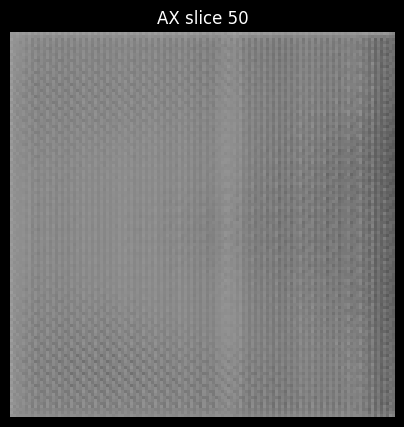

In [32]:
pred = sample_pred  # shape (1, D, H, W)

def show_slice(pred, axis='sag', index=None):
    if axis == 'sag':      # sagittal: keep as-is, use depth index
        vol = pred[0]      # (D, H, W)
        if index is None: index = vol.shape[0] // 2
        img = vol[index]
    elif axis == 'cor':    # coronal: slice along height dimension
        vol = pred[0].permute(1, 0, 2)  # (H, D, W)
        if index is None: index = vol.shape[0] // 2
        img = vol[index]
    elif axis == 'ax':     # axial: slice along width dimension
        vol = pred[0].permute(2, 0, 1)  # (W, D, H)
        if index is None: index = vol.shape[0] // 2
        img = vol[index]
    else:
        raise ValueError("axis must be 'sag', 'cor', or 'ax'")

    plt.figure(figsize=(5,5))
    plt.imshow(img.numpy(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"{axis.upper()} slice {index}")
    plt.axis('off')
    plt.show()

# examples:
#show_slice(pred, axis='cor',index=70)   # coronal view
show_slice(pred, axis='ax', index=50)  # axial slice at index 60
#

## Save Metrics and Plot Motion Traces

This cell saves all computed metrics and visualizes motion tracking across gantry angles.

- Creates an output directory based on the experiment name
- Converts all PyTorch tensors or lists into NumPy arrays for saving
- Saves displacement metrics (LR, SI, AP), angles, Dice, Jacobian, and image quality metrics as `.npy` files
- Sorts traces by gantry angle for consistent plotting
- Plots predicted vs. ground-truth displacements in LR, SI, and AP directions
- Saves the plot as a high-resolution PNG and displays it

This step provides a clear visual and numerical summary of model performance across the test set.


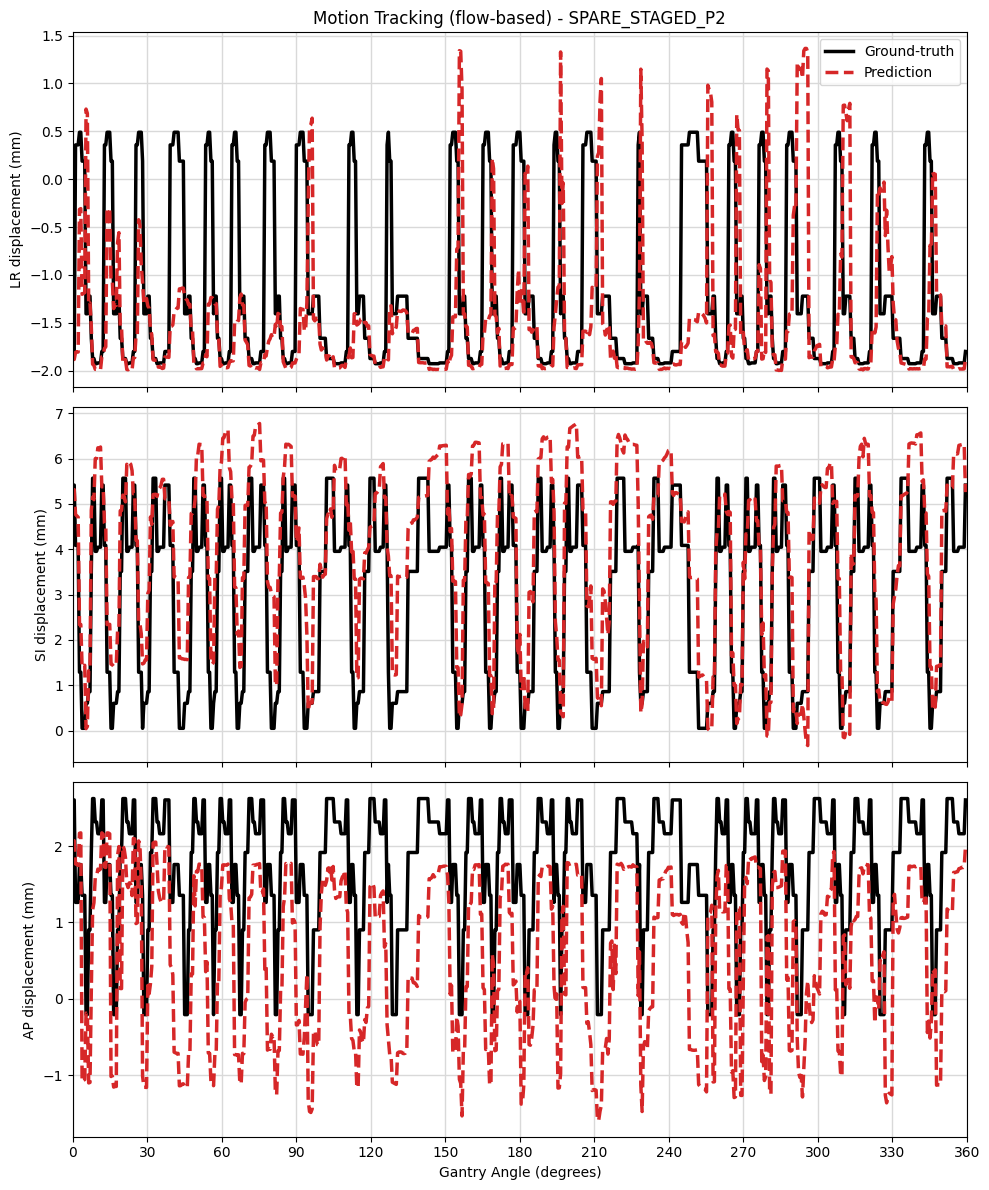

In [17]:

import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# OUTPUT DIRECTORY
# -------------------------
out_dir = os.path.join(plot_dir, f"{expt_file}_Experiment")
os.makedirs(out_dir, exist_ok=True)

# -------------------------
# ENSURE NUMPY
# -------------------------
def as_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if isinstance(x, (list, tuple)):
        out = []
        for v in x:
            if hasattr(v, "detach"):
                if v.numel() == 1:
                    out.append(float(v.detach().cpu().item()))
                else:
                    out.append(v.detach().cpu().numpy())
            else:
                out.append(v)
        return np.asarray(out)
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)

# -------------------------
# SAVE ARRAYS
# -------------------------
np.save(os.path.join(out_dir, "test_angles.npy"), as_numpy(test_angles))
np.save(os.path.join(out_dir, "tar_lr_mm.npy"),   as_numpy(tar_lr))
np.save(os.path.join(out_dir, "tar_si_mm.npy"),   as_numpy(tar_si))
np.save(os.path.join(out_dir, "tar_ap_mm.npy"),   as_numpy(tar_ap))
np.save(os.path.join(out_dir, "pred_lr_mm.npy"),  as_numpy(pred_lr))
np.save(os.path.join(out_dir, "pred_si_mm.npy"),  as_numpy(pred_si))
np.save(os.path.join(out_dir, "pred_ap_mm.npy"),  as_numpy(pred_ap))

if "test_dice" in globals():
    np.save(os.path.join(out_dir, "test_dice.npy"), as_numpy(test_dice))
if "test_detJ" in globals():
    np.save(os.path.join(out_dir, "test_detJ.npy"), as_numpy(test_detJ))
if "test_mse" in globals():
    np.save(os.path.join(out_dir, "stageA_mse.npy"), as_numpy(test_mse))
if "test_ssim" in globals():
    np.save(os.path.join(out_dir, "stageA_ssim.npy"), as_numpy(test_ssim))
if "test_psnr" in globals():
    np.save(os.path.join(out_dir, "stageA_psnr.npy"), as_numpy(test_psnr))
if "stageb_mse" in globals():
    np.save(os.path.join(out_dir, "stageB_mse.npy"), as_numpy(stageb_mse))
if "stageb_ssim" in globals():
    np.save(os.path.join(out_dir, "stageB_ssim.npy"), as_numpy(stageb_ssim))
if "stageb_psnr" in globals():
    np.save(os.path.join(out_dir, "stageB_psnr.npy"), as_numpy(stageb_psnr))

print(f"Metrics saved to: {out_dir}")

# -------------------------
# PLOTTING SETUP
# -------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

def sort_by_angle(trace, angles):
    trace = np.asarray(trace, dtype=float)
    angles = np.asarray(angles, dtype=float)
    order = np.argsort(angles)
    return angles[order], trace[order]

sorted_angles, tar_lr_plot  = sort_by_angle(tar_lr,  test_angles)
_,            tar_si_plot  = sort_by_angle(tar_si,  test_angles)
_,            tar_ap_plot  = sort_by_angle(tar_ap,  test_angles)

_,            pred_lr_plot = sort_by_angle(pred_lr, test_angles)
_,            pred_si_plot = sort_by_angle(pred_si, test_angles)
_,            pred_ap_plot = sort_by_angle(pred_ap, test_angles)

# -------------------------
# CREATE FIGURE
# -------------------------
f, axes = plt.subplots(
    3, 1,
    figsize=(10, 12),
    sharex=True,
    facecolor="white"
)

labels = [
    "LR displacement (mm)",
    "SI displacement (mm)",
    "AP displacement (mm)"
]

tar_data  = [tar_lr_plot,  tar_si_plot,  tar_ap_plot]
pred_data = [pred_lr_plot, pred_si_plot, pred_ap_plot]

for idx, ax in enumerate(axes):
    ax.set_facecolor("white")

    ax.plot(
        sorted_angles,
        tar_data[idx],
        color="black",
        linewidth=2.5,
        label="Ground-truth"
    )

    ax.plot(
        sorted_angles,
        pred_data[idx],
        linestyle="--",
        color="tab:red",
        linewidth=2.5,
        label="Prediction"
    )

    ax.set_ylabel(labels[idx])
    ax.set_xlim([0, 360])
    ax.set_xticks(np.arange(0, 361, 30))
    ax.grid(True, color="0.85", linewidth=1)

    if idx == 0:
        ax.set_title(f"Motion Tracking (flow-based) - {expt_file}")
        ax.legend(loc="upper right", frameon=True)

axes[-1].set_xlabel("Gantry Angle (degrees)")

f.tight_layout()

# -------------------------
# SAVE FIGURE
# -------------------------
out_path = os.path.join(out_dir, f"{expt_file}_trace.png")
plt.savefig(
    out_path,
    dpi=200,
    facecolor="white",
    edgecolor="white"
)

plt.show()


In [18]:

# -------------------------
# PRINT METRIC SUMMARIES
# -------------------------
def print_metric(name, values):
    vals = np.asarray(as_numpy(values), dtype=float)
    print(
        f"{name:<12} | "
        f"mean = {vals.mean():.4f} | "
        f"std = {vals.std():.4f} | "
        f"min = {vals.min():.4f} | "
        f"max = {vals.max():.4f}"
    )

print("\n===== TEST METRICS SUMMARY =====")
print("--- Stage A (Motion) ---")

if "test_dice" in globals():
    print_metric("Dice", test_dice)

if "test_detJ" in globals():
    print_metric("DetJ<=0", test_detJ)

if "test_mse" in globals():
    print_metric("RMSE", test_mse)

if "test_ssim" in globals():
    print_metric("SSIM", test_ssim)

if "test_psnr" in globals():
    print_metric("PSNR", test_psnr)

if "stageb_mse" in globals():
    print("\n--- Stage B (Image) ---")
    print_metric("RMSE", stageb_mse)

if "stageb_ssim" in globals():
    print_metric("SSIM", stageb_ssim)

if "stageb_psnr" in globals():
    print_metric("PSNR", stageb_psnr)

motion_keys = ("tar_lr", "tar_si", "tar_ap", "pred_lr", "pred_si", "pred_ap")
if all(name in globals() for name in motion_keys):
    tar_lr_np = as_numpy(tar_lr).astype(float)
    tar_si_np = as_numpy(tar_si).astype(float)
    tar_ap_np = as_numpy(tar_ap).astype(float)
    pred_lr_np = as_numpy(pred_lr).astype(float)
    pred_si_np = as_numpy(pred_si).astype(float)
    pred_ap_np = as_numpy(pred_ap).astype(float)

    err_3d = np.sqrt(
        (tar_lr_np - pred_lr_np) ** 2 +
        (tar_si_np - pred_si_np) ** 2 +
        (tar_ap_np - pred_ap_np) ** 2
    )

    def _axis_err_stats(target, pred):
        diff = np.abs(target - pred)
        return diff.mean(), diff.std()

    lr_mean, lr_std = _axis_err_stats(tar_lr_np, pred_lr_np)
    si_mean, si_std = _axis_err_stats(tar_si_np, pred_si_np)
    ap_mean, ap_std = _axis_err_stats(tar_ap_np, pred_ap_np)

    print("\n--- Motion Tracking (Centroid) ---")
    print(f"3D Error (mm):   {np.mean(err_3d):.2f} ± {np.std(err_3d):.2f}")
    print("Axis-wise absolute error (mm):")
    print(f"  LR: {lr_mean:.2f} ± {lr_std:.2f}")
    print(f"  SI: {si_mean:.2f} ± {si_std:.2f}")
    print(f"  AP: {ap_mean:.2f} ± {ap_std:.2f}")

print("================================")



===== TEST METRICS SUMMARY =====
--- Stage A (Motion) ---
Dice         | mean = 0.9382 | std = 0.0205 | min = 0.9070 | max = 0.9973
DetJ<=0      | mean = 0.0000 | std = 0.0000 | min = 0.0000 | max = 0.0000
RMSE         | mean = 0.0011 | std = 0.0001 | min = 0.0009 | max = 0.0014
SSIM         | mean = 0.8789 | std = 0.0141 | min = 0.8551 | max = 0.9154
PSNR         | mean = 59.0271 | std = 1.0720 | min = 57.2221 | max = 61.1132

--- Stage B (Image) ---
RMSE         | mean = 0.1547 | std = 0.0004 | min = 0.1541 | max = 0.1558
SSIM         | mean = 0.1261 | std = 0.0021 | min = 0.1202 | max = 0.1342
PSNR         | mean = 16.2080 | std = 0.0230 | min = 16.1503 | max = 16.2455

--- Motion Tracking (Centroid) ---
3D Error (mm):   2.18 ± 0.79
Axis-wise absolute error (mm):
  LR: 0.67 ± 0.85
  SI: 1.22 ± 0.84
  AP: 1.25 ± 0.68
